# Figures for the meeting with Camille

These figures follow the Sep 24 and Oct 1 notes. Everything here uses **existing** samples and probe outputs, so no new training or sampling was needed.

**Model:** the continuous (Ω_m, σ_8)-conditioned diffusion model, trained on N = 64 … 32768 HI maps.

**Test set:** the 32 held-out CAMELS LH cosmologies (sims 900–931). These are real simulations never used to train either the diffusion model or the probe.

**How we read off cosmology:** a frozen VGG probe that maps one 2-D map to (Ω_m, σ_8, …). The **same probe** is applied to
* the **real** held-out maps (128 slices per cosmology), which tests the probe itself, and
* the **generated** maps (64 per cosmology, made by asking the diffusion model for that cosmology).

So everything is tested on the real held-out data. The real maps tell us how well the probe can possibly do, and the generated maps are compared against that.

| Camille asked | Where |
|---|---|
| The picture: true distribution, sparse training sims, "fake holes" | Fig. 1 (cartoon) |
| Is this tested on real held-out data? | Yes: Fig. 3 (same probe on real and generated maps) |
| Test cosmologies in both dense and sparse parts of parameter space | Fig. 2, Fig. 4 |
| TARP plot | Fig. 5 (with the real-map TARP as reference) |
| Hold out 100 cosmologies; check that training on 900 sims doesn't change results | Next steps (needs retraining) |

In [1]:
%matplotlib inline
from datetime import datetime
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

PROJECT_DIR = Path('/home/jiamingp/diffusion_models_repo')
FIG_DIR = PROJECT_DIR / 'results' / f"camille_meeting_figures_{datetime.now():%Y%m%d_%H%M%S}"
FIG_DIR.mkdir(parents=True, exist_ok=False)   # fresh folder every run; nothing is overwritten

plt.rcParams.update({'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.titlesize': 12, 'legend.frameon': False, 'savefig.bbox': 'tight'})

def save(fig, name):
    for ext in ('png', 'pdf'):
        fig.savefig(FIG_DIR / f'{name}.{ext}', dpi=200)

SWEEP = 'nf_conditional_omsig_continuous_200k'
SIZES = [64, 256, 1024, 4096, 32768]
TEST = np.arange(900, 932)
LO, HI = np.array([0.1, 0.6]), np.array([0.5, 1.0])      # CAMELS LH prior box for (Omega_m, sigma_8)
COLORS = dict(zip(SIZES, plt.get_cmap('viridis')(np.linspace(0.05, 0.9, len(SIZES)))))

PARAMS = np.loadtxt('/scratch/huterer_root/huterer0/CAMELS/CMD/3d_grids/IllustrisTNG/params_LH_IllustrisTNG.txt')[:, :2]
manifest = {r['dataset_size']: r for r in json.loads((PROJECT_DIR / 'local' / SWEEP / 'manifest.json').read_text())}
train_sims = {n: np.unique(pd.read_csv(manifest[n]['selected_pairs_path']).simulation_index) for n in SIZES}
assert not any(np.isin(TEST, s).any() for s in train_sims.values()), 'a test sim is in a training set'

pred = pd.read_csv(PROJECT_DIR / 'results' / SWEEP / 'calibration_vgg' / 'bias_probe_per_sample_predictions.csv')
pred = pred[(pred.guidance_label == 'noguidance') & (pred.cfg_dropout == 0) & pred.parameter.isin(['Omega_m', 'sigma_8'])]
# draws[n]: (32 cosmologies, 64 maps, 2 params) probe readings; truth: (32, 2)
draws = {}
for n in SIZES:
    d = pred[pred.dataset_size == n].pivot_table(index=['heldout_sim', 'seed_index'], columns='parameter', values='theta_rec')
    draws[n] = d.loc[TEST, ['Omega_m', 'sigma_8']].to_numpy().reshape(32, 64, 2)
truth = PARAMS[TEST]
assert np.allclose(pred[pred.parameter == 'Omega_m'].groupby('heldout_sim').theta_in.first().loc[TEST], truth[:, 0], atol=1e-5)
# Same probe on the real held-out maps: the identity rows of the probe transform-control run.
PROBE = json.loads((PROJECT_DIR / 'results' / SWEEP / 'calibration_vgg' / 'bias_probe_eval_metadata.json').read_text())['encoder_path']
CTRL = PROJECT_DIR / 'results/nf_conditional_bias_probe/transform_controls'
import hashlib
assert json.loads((CTRL / 'manifest.json').read_text())['encoder']['sha256'] == hashlib.sha256(Path(PROBE).read_bytes()).hexdigest(), \
    'real-map readings come from a different probe'
chunks = pd.read_csv(CTRL / 'probe_transform_predictions.csv', chunksize=500_000,
                     usecols=['transform', 'sim_index', 'z_index', 'parameter', 'theta_true', 'theta_pred'])
real_long = pd.concat(c[(c['transform'] == 'identity') & c['parameter'].isin(['Omega_m', 'sigma_8'])] for c in chunks)
r = real_long.pivot_table(index=['sim_index', 'z_index'], columns='parameter', values='theta_pred')
real_draws = r.loc[TEST, ['Omega_m', 'sigma_8']].to_numpy().reshape(32, -1, 2)          # (32 cosmologies, 128 slices, 2)
assert np.allclose(real_long[real_long.parameter == 'Omega_m'].groupby('sim_index').theta_true.first().loc[TEST], truth[:, 0], atol=1e-5)

def summary(d):
    # per-cosmology median and 68% range of the readings, coverage, bias
    med = np.median(d, axis=1); q16, q84 = np.quantile(d, [0.16, 0.84], axis=1)
    return dict(med=med, q16=q16, q84=q84, cov=((q16 <= truth) & (truth <= q84)).mean(0),
                bias=(med - truth).mean(0), width=np.median(q84 - q16, axis=0))
REAL = summary(real_draws)
W_REAL = REAL['width'][0]                                # probe's 68% width on real held-out maps (Omega_m)
print('probe:', PROBE)
print({n: len(s) for n, s in train_sims.items()}, 'training simulations per N')
print(f"real held-out maps, {real_draws.shape[1]} slices each: 68% coverage Om {REAL['cov'][0]:.2f}, s8 {REAL['cov'][1]:.2f}; "
      f"W(Om) = {W_REAL:.4f}")

probe: /home/jiamingp/diffusion_models_repo/results/nf_conditional_bias_probe/encoder/vgg_mlp_encoder.npz
{64: 64, 256: 256, 1024: 968, 4096: 968, 32768: 968} training simulations per N
real held-out maps, 128 slices each: 68% coverage Om 0.84, s8 0.44; W(Om) = 0.0931


## Fig. 1 — The idea (cartoon, not data)

* **Orange:** the true distribution of cosmologies.
* **Black ticks:** the simulations we can afford, so they're sparse.
* **Blue:** what you learn from those simulations alone. It has a **fake hole** wherever there happen to be no simulations.
* **Green:** the diffusion model can make maps at any requested cosmology, including inside the hole, so the learned distribution no longer has the gap.

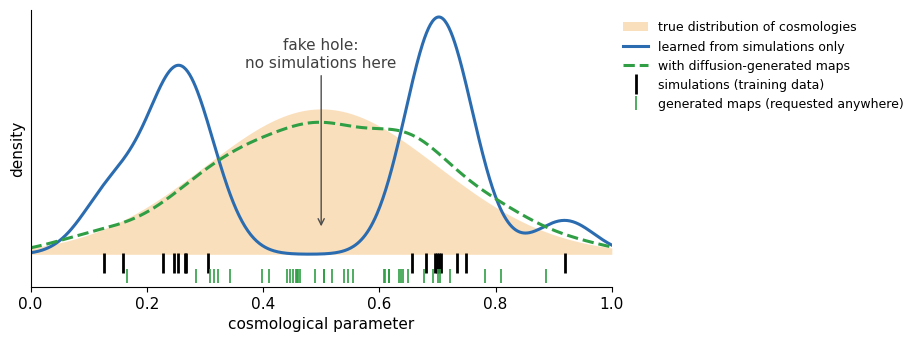

In [2]:
rng = np.random.default_rng(3)
x = np.linspace(0, 1, 600)
true_pdf = np.exp(-0.5 * ((x - 0.5) / 0.2) ** 2); true_pdf /= np.trapz(true_pdf, x)
sims = np.sort(np.r_[rng.normal(0.28, 0.06, 9), rng.normal(0.72, 0.06, 9)])
sims = sims[(sims < 0.4) | (sims > 0.6)]                                            # sparse sims, gap near 0.5
kde = lambda pts, h: np.exp(-0.5 * ((x[:, None] - pts[None]) / h) ** 2).sum(1) / (len(pts) * h * np.sqrt(2 * np.pi))
new = rng.normal(0.5, 0.2, 400); new = new[(new > 0) & (new < 1)]                    # maps generated at requested cosmologies
gen = np.r_[sims, new]
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.fill_between(x, true_pdf, color='#F2A541', alpha=0.35, lw=0, label='true distribution of cosmologies')
ax.plot(x, kde(sims, 0.05), color='#2B6CB0', lw=2.2, label='learned from simulations only')
ax.plot(x, kde(gen, 0.06), color='#2F9E44', lw=2.2, ls='--', label='with diffusion-generated maps')
ax.plot(sims, np.full_like(sims, -0.12), '|', color='k', ms=14, mew=2, label='simulations (training data)')
ax.plot(new[:40], np.full(40, -0.3), '|', color='#2F9E44', ms=10, mew=1.2, label='generated maps (requested anywhere)')
ax.annotate('fake hole:\nno simulations here', xy=(0.5, 0.35), xytext=(0.5, 2.6), ha='center',
            arrowprops=dict(arrowstyle='->', color='0.3'), color='0.25')
ax.set_xlabel('cosmological parameter'); ax.set_yticks([]); ax.set_ylabel('density')
ax.set_xlim(0, 1); ax.set_ylim(-0.45, 3.4)
ax.legend(loc='upper left', fontsize=9, bbox_to_anchor=(1.0, 1.0))
save(fig, 'fig1_cartoon_fake_holes'); plt.show()

## Fig. 2 — Where are the training and test cosmologies?

Each panel is the (Ω_m, σ_8) plane of the CAMELS LH box:
* **Black dots:** the simulations used for training at that N.
* **Red stars:** the 32 test cosmologies, which are never used in training.

N counts training **maps**, and each simulation contributes 2-D slices.
* At N = 64 and 256, every map comes from a different simulation, so training covers only 64 or 256 cosmologies. Many test stars sit far from any training point; those are the "sparse" cases.
* From N = 1024 up, training uses all 968 non-test simulations, so every test cosmology has close neighbours.

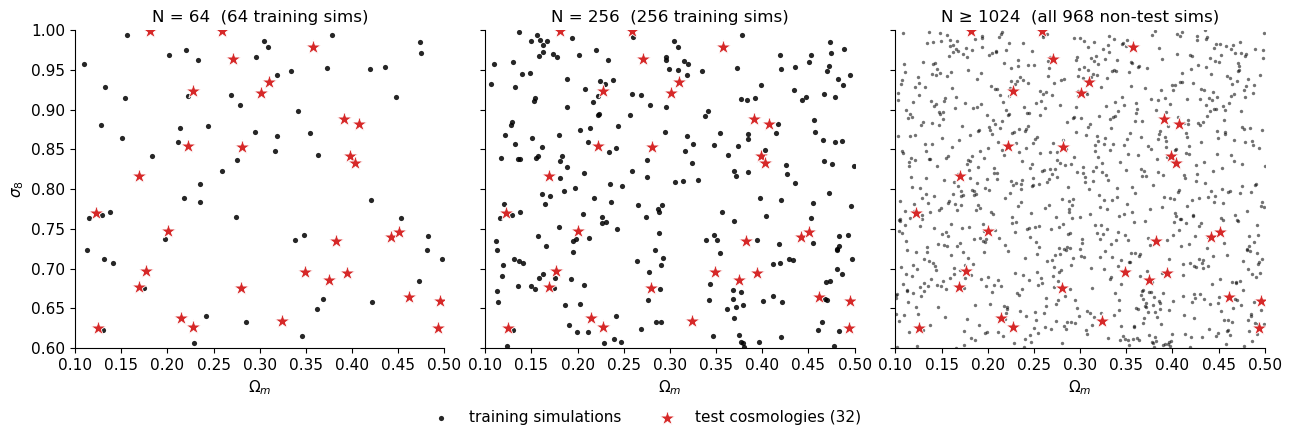

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharex=True, sharey=True)
for ax, n, title in zip(axes, [64, 256, 1024], ['N = 64  (64 training sims)', 'N = 256  (256 training sims)', 'N ≥ 1024  (all 968 non-test sims)']):
    s = train_sims[n]
    ax.scatter(*PARAMS[s].T, s=6 if len(s) > 300 else 14, color='k', alpha=0.55 if len(s) > 300 else 0.85, lw=0,
               label='training simulations')
    ax.scatter(*truth.T, marker='*', s=130, color='#D62828', edgecolor='white', lw=0.6, label='test cosmologies (32)', zorder=3)
    ax.set_title(title); ax.set_xlabel(r'$\Omega_m$'); ax.set_xlim(LO[0], HI[0]); ax.set_ylim(LO[1], HI[1])
axes[0].set_ylabel(r'$\sigma_8$')
fig.legend(*axes[0].get_legend_handles_labels(), loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.06))
fig.tight_layout(); save(fig, 'fig2_training_vs_test_cosmologies'); plt.show()

## Fig. 3 — Same probe, same 32 held-out cosmologies: real maps vs generated maps

Each point is one held-out cosmology: the median probe reading, with the 16–84% range as the error bar, against the true value. The dashed line is perfect recovery.
* **Left (black): real held-out simulation maps.** This tests the probe itself, on data it never saw.
* **Middle and right: maps generated by the diffusion model** at those same cosmologies, for the largest and the smallest training sets.

The probe measures **Ω_m well** on real maps. It measures **σ_8 only weakly**: the readings are pulled toward the middle of the range, and the 68% coverage is low even on real maps. So any σ_8 result, including the joint TARP, is limited by the probe, not only by the diffusion model.

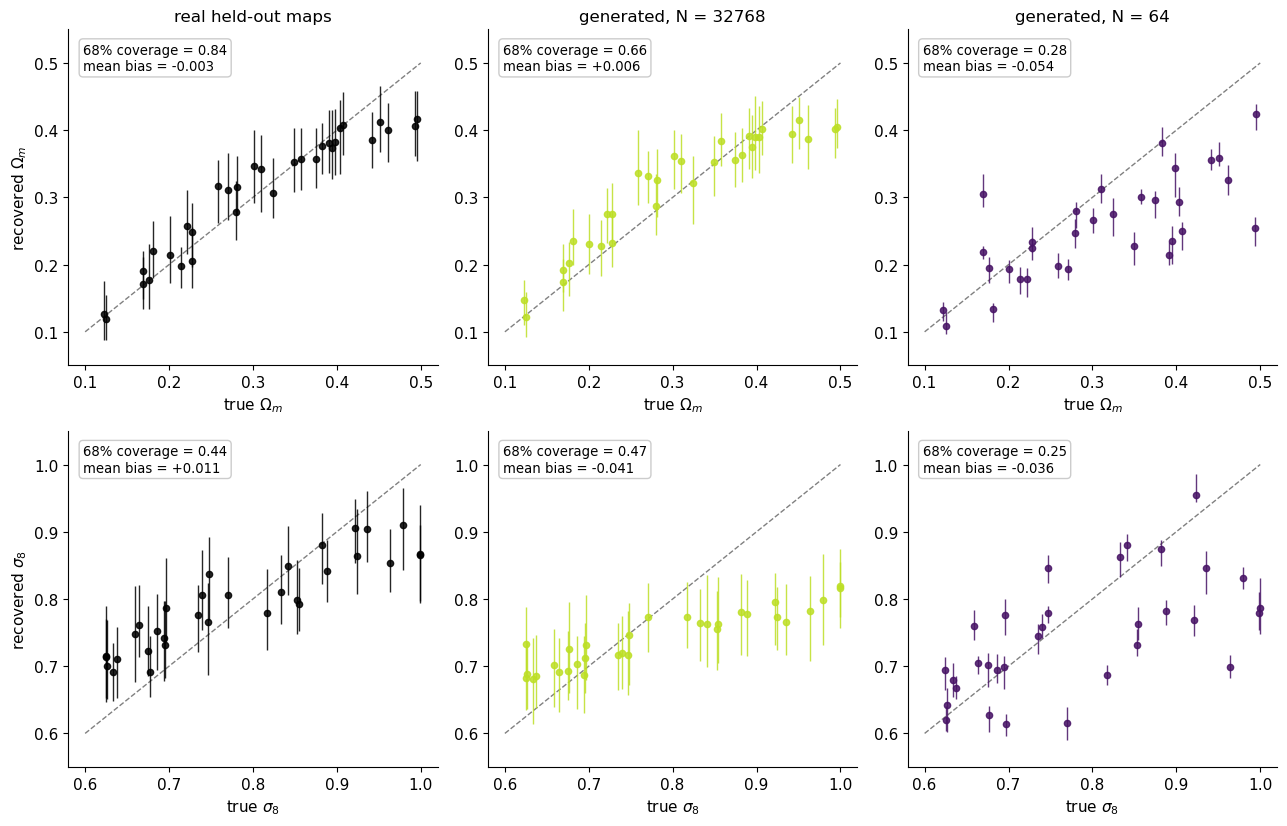

,maps,parameter,68% coverage,mean bias,median 68% width
0,real held-out maps,Omega_m,0.844,-0.003,0.093
1,real held-out maps,sigma_8,0.438,0.011,0.111
2,"generated, N = 32768",Omega_m,0.656,0.006,0.083
3,"generated, N = 32768",sigma_8,0.469,-0.041,0.109
4,"generated, N = 64",Omega_m,0.281,-0.054,0.039
5,"generated, N = 64",sigma_8,0.250,-0.036,0.043


In [4]:
panels = [('real held-out maps', 'k', REAL), ('generated, N = 32768', COLORS[32768], summary(draws[32768])),
          ('generated, N = 64', COLORS[64], summary(draws[64]))]
fig, axes = plt.subplots(2, 3, figsize=(13, 8.4))
for col, (title, color, s) in enumerate(panels):
    for row, (j, name) in enumerate([(0, r'$\Omega_m$'), (1, r'$\sigma_8$')]):
        ax = axes[row, col]
        ax.plot([LO[j], HI[j]], [LO[j], HI[j]], color='0.5', ls='--', lw=1)
        ax.errorbar(truth[:, j], s['med'][:, j], yerr=[s['med'][:, j] - s['q16'][:, j], s['q84'][:, j] - s['med'][:, j]],
                    fmt='o', ms=4.5, color=color, ecolor=color, elinewidth=1, alpha=0.85)
        ax.text(0.04, 0.96, f"68% coverage = {s['cov'][j]:.2f}\nmean bias = {s['bias'][j]:+.3f}", transform=ax.transAxes,
                va='top', fontsize=9.5, bbox=dict(facecolor='white', edgecolor='0.8', boxstyle='round,pad=0.3'))
        ax.set_xlim(LO[j] - 0.02, HI[j] + 0.02); ax.set_ylim(LO[j] - 0.05, HI[j] + 0.05)
        ax.set_xlabel(f'true {name}'); ax.set_ylabel(f'recovered {name}' if col == 0 else '')
        if row == 0: ax.set_title(title)
fig.tight_layout(); save(fig, 'fig3_real_vs_generated_same_probe'); plt.show()
pd.DataFrame([{'maps': t, 'parameter': p, '68% coverage': s['cov'][j], 'mean bias': s['bias'][j], 'median 68% width': s['width'][j]}
              for t, _, s in panels for j, p in enumerate(['Omega_m', 'sigma_8'])]).round(3)

## Fig. 4 — Do sparse test cosmologies come out worse?

For each test cosmology:
* **"Sparseness"** is the distance to the nearest training cosmology. We measure it in the (Ω_m, σ_8) box rescaled to a unit square, because those are the two parameters the model is conditioned on.
* **Error** is |median recovered Ω_m − true Ω_m|, in units of W ≈ 0.09, the probe's 68% width on real held-out maps (Fig. 3).
* **Filled points** have the truth inside the 68% range of the 64 generated maps; **open points** miss it.
* **The gray dashed line** is the probe's typical error on the real test maps, which is the best we can hope for with this probe.

Only N = 64 and 256 are shown, because from N = 1024 up every test cosmology has a close neighbour.

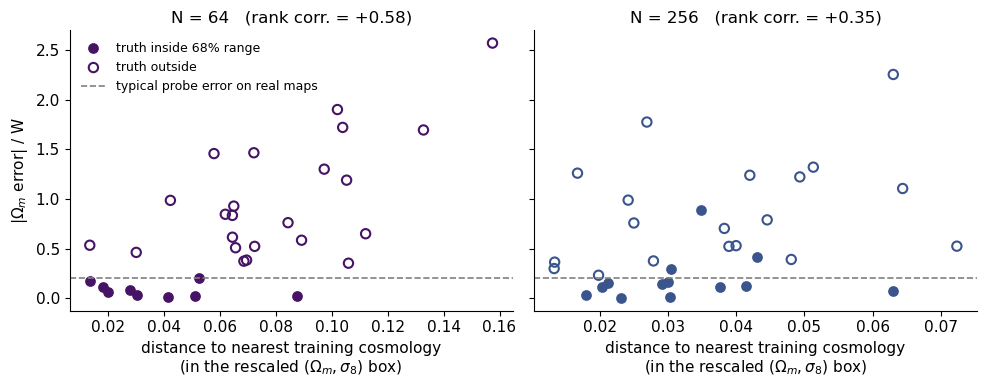

,N,test cosmologies,count,mean |error| / W,68% coverage
0,64,dense half,16,0.46,0.50
1,64,sparse half,16,1.00,0.06
2,256,dense half,16,0.43,0.50
3,256,sparse half,16,0.76,0.31


In [5]:
unit = lambda t: (t - LO) / (HI - LO)
def nn_dist(n):
    return np.linalg.norm(unit(truth)[:, None] - unit(PARAMS[train_sims[n]])[None], axis=-1).min(1)

rows = []
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
real_err = np.median(np.abs(REAL['med'][:, 0] - truth[:, 0])) / W_REAL
for ax, n in zip(axes, [64, 256]):
    dist = nn_dist(n)
    med = np.median(draws[n][..., 0], axis=1)
    q16, q84 = np.quantile(draws[n][..., 0], [0.16, 0.84], axis=1)
    err = np.abs(med - truth[:, 0]) / W_REAL
    cov = (q16 <= truth[:, 0]) & (truth[:, 0] <= q84)
    ax.scatter(dist[cov], err[cov], s=45, color=COLORS[n], label='truth inside 68% range')
    ax.scatter(dist[~cov], err[~cov], s=45, facecolor='none', edgecolor=COLORS[n], lw=1.5, label='truth outside')
    ax.axhline(real_err, color='0.5', ls='--', lw=1.2, label='typical probe error on real maps')
    rho = spearmanr(dist, err).correlation
    ax.set_title(f'N = {n}   (rank corr. = {rho:+.2f})')
    ax.set_xlabel('distance to nearest training cosmology\n' + r'(in the rescaled $(\Omega_m, \sigma_8)$ box)')
    sparse = dist > np.median(dist)
    for label, m in [('dense half', ~sparse), ('sparse half', sparse)]:
        rows.append({'N': n, 'test cosmologies': label, 'count': int(m.sum()),
                     'mean |error| / W': err[m].mean(), '68% coverage': cov[m].mean()})
axes[0].set_ylabel(r'$|\Omega_m$ error$|$ / W'); axes[0].legend(fontsize=9)
fig.tight_layout(); save(fig, 'fig4_error_vs_sparseness'); plt.show()
dense_sparse = pd.DataFrame(rows); dense_sparse.to_csv(FIG_DIR / 'fig4_dense_vs_sparse.csv', index=False)
dense_sparse.round(2)

## Fig. 5 — TARP calibration test (Ω_m and σ_8 together)

TARP (Lemos et al. 2023) checks the **joint** 2-D distribution. For each test cosmology we pick random reference points in the prior box. For each reference point we ask what fraction of the 64 generated readings lie closer to it than the true cosmology does. If the generated spread is honest, that fraction is uniform, and the curve follows the **diagonal**.

* **Gray band:** how far off the diagonal a *perfectly calibrated* result can wander with only 32 test cosmologies. We build it by treating one generated map as if it were the truth.
* **Curve outside the band:** miscalibration, meaning the error bars are too narrow and/or biased.
* **First panel (black): the same TARP for the real held-out maps** (128 per cosmology). This is the best this probe can do. Because the probe reads σ_8 weakly (Fig. 3), even real maps are not on the diagonal, so compare the diffusion-model curves with this panel, not only with the diagonal.

**Caveat:** these 64 readings are a *recovery ensemble* (probe readings of maps generated at the true cosmology), not yet a posterior inferred from one map. A proper TARP for "infer cosmology from one map" needs a posterior estimator; see next steps.

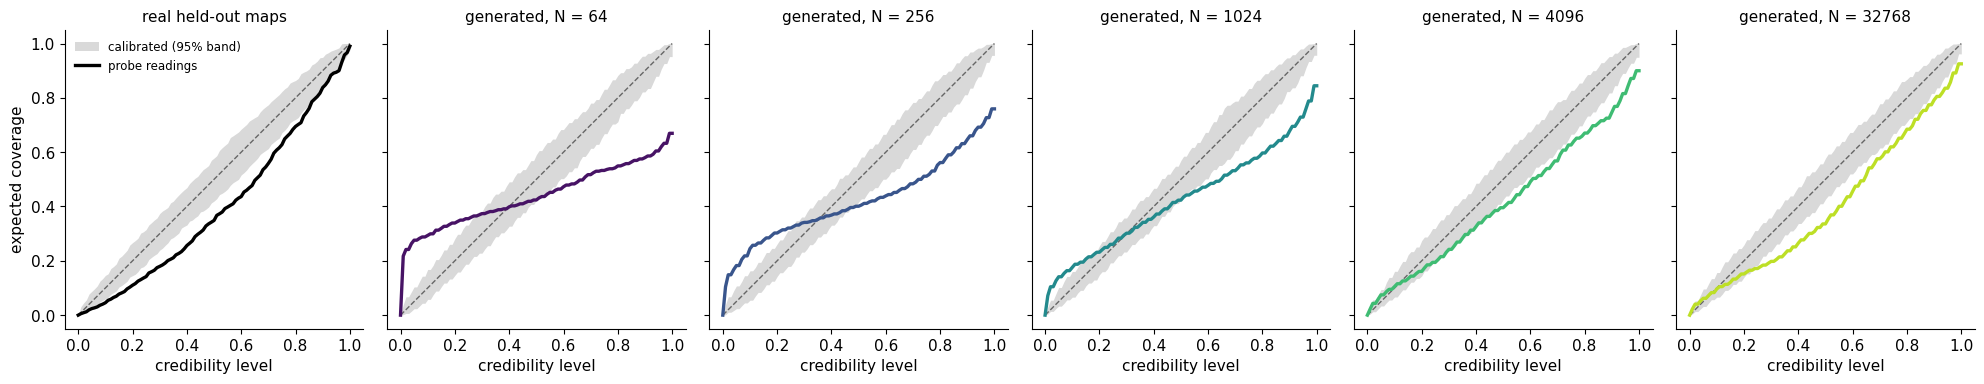

,maps,max |ECP - level|,fraction of levels outside band
0,real held-out maps,0.16,0.87
1,"generated, N = 64",0.35,0.76
2,"generated, N = 256",0.26,0.76
3,"generated, N = 1024",0.23,0.62
4,"generated, N = 4096",0.16,0.69
5,"generated, N = 32768",0.16,0.77


In [6]:
LEVELS = np.linspace(0, 1, 101)
def tarp_ecp(samples, truths, rng, n_ref=200):
    s, t = unit(samples), unit(truths)
    refs = rng.uniform(size=(n_ref, len(t), 2))
    r_true = np.linalg.norm(t[None] - refs, axis=-1)
    frac = (np.linalg.norm(s[None] - refs[:, :, None], axis=-1) < r_true[..., None]).mean(-1)
    return (frac[..., None] < LEVELS).mean(axis=(0, 1))

rng = np.random.default_rng(123)
def null_band(d):
    # calibrated by construction: one draw plays the truth, the others are the ensemble
    m, out = d.shape[1], []
    for _ in range(200):
        j = rng.integers(m, size=32)
        keep = np.ones((32, m), bool); keep[np.arange(32), j] = False
        out.append(tarp_ecp(d[keep].reshape(32, m - 1, 2), d[np.arange(32), j], rng, n_ref=50))
    return np.quantile(out, [0.025, 0.975], axis=0)

sets = [('real held-out maps', 'k', real_draws)] + [(f'generated, N = {n}', COLORS[n], draws[n]) for n in SIZES]
fig, axes = plt.subplots(1, 6, figsize=(20, 3.9), sharey=True)
tarp_rows = []
for ax, (title, color, d) in zip(axes, sets):
    lo, hi = null_band(d)
    ecp = tarp_ecp(d, truth, rng)
    ax.fill_between(LEVELS, lo, hi, color='0.85', lw=0, label='calibrated (95% band)')
    ax.plot([0, 1], [0, 1], color='0.4', ls='--', lw=1)
    ax.plot(LEVELS, ecp, color=color, lw=2.4, label='probe readings')
    ax.set_title(title, fontsize=11); ax.set_xlabel('credibility level'); ax.set_aspect('equal')
    tarp_rows.append({'maps': title, 'max |ECP - level|': np.abs(ecp - LEVELS).max(),
                      'fraction of levels outside band': np.mean((ecp < lo) | (ecp > hi))})
axes[0].set_ylabel('expected coverage'); axes[0].legend(loc='upper left', fontsize=8.5)
fig.tight_layout(); save(fig, 'fig5_tarp_omega_m_sigma_8'); plt.show()
tarp_table = pd.DataFrame(tarp_rows); tarp_table.to_csv(FIG_DIR / 'fig5_tarp_summary.csv', index=False)
tarp_table.round(2)

## Summary and next steps

**1. The probe is tested on the real held-out data (Fig. 3).** These are the same 32 cosmologies and the same probe, applied to the real simulation maps:

| maps | Ω_m 68% coverage | Ω_m mean bias | σ_8 68% coverage |
|---|---|---|---|
| real held-out maps | **0.84** | −0.003 | 0.44 |
| generated, N = 32768 | 0.66 | +0.006 | 0.47 |
| generated, N = 64 | 0.28 | −0.054 | 0.25 |

* Ω_m is read well from real maps.
* σ_8 is read only weakly even from real maps: values are pulled toward the middle of the range. That is a limit of the probe, not of the diffusion model.
* At N = 32768 the generated maps behave much like the real ones.
* At N = 64 the error bars collapse (68% width 0.039 vs 0.093 on real maps), so the truth falls outside them. That is the memorization regime.

**2. Sparse test cosmologies are where it fails (Fig. 4).**

| N | test cosmologies | mean error / W | 68% coverage |
|---|---|---|---|
| 64 | dense half | 0.46 | 0.50 |
| 64 | sparse half | **1.00** | **0.06** |
| 256 | dense half | 0.43 | 0.50 |
| 256 | sparse half | **0.76** | **0.31** |

With no training simulation nearby, the generated maps read as the wrong cosmology, with error bars too small to cover the truth. This is the "fake hole" from Fig. 1, seen in real data. There are only 16 cosmologies per half, so the numbers are noisy.

**3. TARP (Fig. 5).**
* Even the **real** maps are not on the diagonal, because the probe pulls σ_8, and the highest Ω_m values, toward the middle.
* At **N = 4096 and 32768** the diffusion model's curve is about as far off the diagonal as the real maps' curve (largest deviation 0.16 for all three). At large N, the model is about as well calibrated as this probe allows.
* At **N ≤ 1024** the S-shape means the error bars are too narrow; that's memorization.

**4. Next steps.**
* **100 held-out cosmologies (sims 900–999).** The current models train on every non-test simulation, which includes sims 932–999. Holding out 900–999 means retraining on sims 0–899 only. That retraining is also Camille's check that "training on 900 doesn't change the results".
* **True one-map posterior.** The TARP here uses probe readings of many maps per cosmology. Camille's version, inferring cosmology from one map, needs a posterior estimator, which could be trained on generated maps. A better σ_8 probe would also help.


In [7]:
cov68 = {n: np.mean([(np.quantile(draws[n][i, :, 0], .16) <= truth[i, 0] <= np.quantile(draws[n][i, :, 0], .84)) for i in range(32)]) for n in SIZES}
print('Omega_m 68% coverage by N:', {n: round(v, 2) for n, v in cov68.items()}, '| real maps:', round(REAL['cov'][0], 2))
print('Figures and tables in', FIG_DIR)

Omega_m 68% coverage by N: {64: 0.28, 256: 0.41, 1024: 0.31, 4096: 0.75, 32768: 0.66} | real maps: 0.84
Figures and tables in /home/jiamingp/diffusion_models_repo/results/camille_meeting_figures_20261006_160636
